In [111]:
import os

# Set to project root explicitly
project_root = r'c:\Projects\traffic-congestion-prediction'
os.chdir(project_root)
print("Working directory:", os.getcwd())

Working directory: c:\Projects\traffic-congestion-prediction


In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Libraries imported successfully")

Libraries imported successfully


In [113]:
# Load raw data
df = pd.read_csv('data/raw/traffic_speed_data.csv')

# Load reference tables
time_info = pd.read_csv('data/raw/time_information_table.csv')
day_info = pd.read_csv('data/raw/day_information_table.csv')

# Merge all three tables
df_merged = df.merge(time_info[['time_id', 'start_time']], 
                     on='time_id', how='left')
df_merged = df_merged.merge(day_info, 
                             on='day_id', how='left')

# Convert date to datetime
df_merged['date'] = pd.to_datetime(df_merged['date'])

# Extract time features
df_merged['hour'] = pd.to_datetime(
    df_merged['start_time'], format='%H:%M:%S').dt.hour
df_merged['weekday'] = df_merged['date'].dt.weekday
df_merged['is_weekend'] = (df_merged['weekday'] >= 5).astype(int)

# Remove outliers
df_merged = df_merged[df_merged['speed'] <= 100]
df_merged = df_merged[df_merged['speed'] >= 1]

# Define congestion label
THRESHOLD = 30
df_merged['congestion'] = (df_merged['speed'] < THRESHOLD).astype(int)

print(f"Data loaded successfully!")
print(f"Shape: {df_merged.shape}")
print(f"Columns: {df_merged.columns.tolist()}")

Data loaded successfully!
Shape: (1855572, 10)
Columns: ['road_id', 'day_id', 'time_id', 'speed', 'start_time', 'date', 'hour', 'weekday', 'is_weekend', 'congestion']


In [114]:
# Sort by road_id, date, time_id chronologically
df_merged = df_merged.sort_values(
    by=['road_id', 'date', 'time_id']
).reset_index(drop=True)

print("Data sorted chronologically")
print(f"\nFirst 3 rows:")
print(df_merged[['road_id', 'date', 
                  'start_time', 'speed']].head(3))
print(f"\nLast 3 rows:")
print(df_merged[['road_id', 'date', 
                  'start_time', 'speed']].tail(3))

Data sorted chronologically

First 3 rows:
   road_id       date start_time   speed
0        1 2016-08-01    0:00:00  40.893
1        1 2016-08-01    0:10:00  41.938
2        1 2016-08-01    0:20:00  44.098

Last 3 rows:
         road_id       date start_time   speed
1855569      214 2016-09-30   23:30:00  51.266
1855570      214 2016-09-30   23:40:00  51.352
1855571      214 2016-09-30   23:50:00  52.402


In [115]:
# Create lag features per road segment
df_merged = df_merged.sort_values(['road_id', 'date', 'time_id'])

for lag in [1, 2, 3, 6]:
    df_merged[f'speed_lag_{lag}'] = df_merged.groupby(
        'road_id')['speed'].shift(lag)

print("Lag features created:")
print("speed_lag_1 = speed 10 min ago")
print("speed_lag_2 = speed 20 min ago")
print("speed_lag_3 = speed 30 min ago")
print("speed_lag_6 = speed 60 min ago")
print(f"\nSample:")
print(df_merged[['road_id', 'start_time', 'speed', 
                  'speed_lag_1', 'speed_lag_2', 
                  'speed_lag_3', 'speed_lag_6']].head(8))

Lag features created:
speed_lag_1 = speed 10 min ago
speed_lag_2 = speed 20 min ago
speed_lag_3 = speed 30 min ago
speed_lag_6 = speed 60 min ago

Sample:
   road_id start_time   speed  speed_lag_1  speed_lag_2  speed_lag_3  \
0        1    0:00:00  40.893          NaN          NaN          NaN   
1        1    0:10:00  41.938       40.893          NaN          NaN   
2        1    0:20:00  44.098       41.938       40.893          NaN   
3        1    0:30:00  44.483       44.098       41.938       40.893   
4        1    0:40:00  44.172       44.483       44.098       41.938   
5        1    0:50:00  44.416       44.172       44.483       44.098   
6        1    1:00:00  43.622       44.416       44.172       44.483   
7        1    1:10:00  44.202       43.622       44.416       44.172   

   speed_lag_6  
0          NaN  
1          NaN  
2          NaN  
3          NaN  
4          NaN  
5          NaN  
6       40.893  
7       41.938  


In [116]:
# Rolling statistics per road segment
df_merged['speed_rolling_mean_3'] = df_merged.groupby(
    'road_id')['speed'].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean())

df_merged['speed_rolling_std_3'] = df_merged.groupby(
    'road_id')['speed'].transform(
    lambda x: x.rolling(window=3, min_periods=1).std())

print("Rolling features created:")
print("speed_rolling_mean_3 = avg speed last 30 min")
print("speed_rolling_std_3  = std speed last 30 min")
print(f"\nSample:")
print(df_merged[['road_id', 'start_time', 'speed',
                  'speed_rolling_mean_3', 
                  'speed_rolling_std_3']].head(8))

Rolling features created:
speed_rolling_mean_3 = avg speed last 30 min
speed_rolling_std_3  = std speed last 30 min

Sample:
   road_id start_time   speed  speed_rolling_mean_3  speed_rolling_std_3
0        1    0:00:00  40.893             40.893000                  NaN
1        1    0:10:00  41.938             41.415500             0.738927
2        1    0:20:00  44.098             42.309667             1.634506
3        1    0:30:00  44.483             43.506333             1.371790
4        1    0:40:00  44.172             44.251000             0.204296
5        1    0:50:00  44.416             44.357000             0.163680
6        1    1:00:00  43.622             44.070000             0.406709
7        1    1:10:00  44.202             44.080000             0.410819


In [117]:
# Create target: congestion 20 minutes ahead
# shift(-2) means 2 time steps forward = 20 minutes
df_merged['congestion_t20'] = df_merged.groupby(
    'road_id')['congestion'].shift(-2)

print("Target variable created: congestion_t20")
print("= Will there be congestion in 20 minutes?")
print(f"\nSample:")
print(df_merged[['road_id', 'start_time', 'speed',
                  'congestion', 
                  'congestion_t20']].head(8))
print(f"\nTarget distribution:")
print(df_merged['congestion_t20'].value_counts())

Target variable created: congestion_t20
= Will there be congestion in 20 minutes?

Sample:
   road_id start_time   speed  congestion  congestion_t20
0        1    0:00:00  40.893           0             0.0
1        1    0:10:00  41.938           0             0.0
2        1    0:20:00  44.098           0             0.0
3        1    0:30:00  44.483           0             0.0
4        1    0:40:00  44.172           0             0.0
5        1    0:50:00  44.416           0             0.0
6        1    1:00:00  43.622           0             0.0
7        1    1:10:00  44.202           0             0.0

Target distribution:
congestion_t20
0.0    1509186
1.0     345958
Name: count, dtype: int64


In [118]:
# Validate t+20 target on road 1
road1 = df_merged[df_merged['road_id'] == 1][
    ['road_id', 'date', 'start_time', 
     'speed', 'congestion', 'congestion_t20']
].head(10)

print("=== Target Validation – Road 1 ===")
print(road1.to_string())
print("\nVerification:")
print("Row 0 congestion_t20 should match Row 2 congestion")
print(f"Row 0 congestion_t20: {road1.iloc[0]['congestion_t20']}")
print(f"Row 2 congestion:     {road1.iloc[2]['congestion']}")
print(f"Match: {road1.iloc[0]['congestion_t20'] == road1.iloc[2]['congestion']}")

=== Target Validation – Road 1 ===
   road_id       date start_time   speed  congestion  congestion_t20
0        1 2016-08-01    0:00:00  40.893           0             0.0
1        1 2016-08-01    0:10:00  41.938           0             0.0
2        1 2016-08-01    0:20:00  44.098           0             0.0
3        1 2016-08-01    0:30:00  44.483           0             0.0
4        1 2016-08-01    0:40:00  44.172           0             0.0
5        1 2016-08-01    0:50:00  44.416           0             0.0
6        1 2016-08-01    1:00:00  43.622           0             0.0
7        1 2016-08-01    1:10:00  44.202           0             0.0
8        1 2016-08-01    1:20:00  42.898           0             0.0
9        1 2016-08-01    1:30:00  44.123           0             0.0

Verification:
Row 0 congestion_t20 should match Row 2 congestion
Row 0 congestion_t20: 0.0
Row 2 congestion:     0
Match: True


In [119]:
# Rush hour flag based on EDA findings
df_merged['is_rush_hour'] = (
    (df_merged['hour'].isin([7, 8, 9, 17, 18, 19])) & 
    (df_merged['is_weekend'] == 0)
).astype(int)

print("Rush hour feature created")
print(f"\nRush hour distribution:")
print(df_merged['is_rush_hour'].value_counts())
print(f"\nAverage congestion during rush hour: "
      f"{df_merged[df_merged['is_rush_hour']==1]['congestion'].mean()*100:.1f}%")
print(f"Average congestion outside rush hour: "
      f"{df_merged[df_merged['is_rush_hour']==0]['congestion'].mean()*100:.1f}%")

Rush hour feature created

Rush hour distribution:
is_rush_hour
0    1513314
1     342258
Name: count, dtype: int64

Average congestion during rush hour: 36.6%
Average congestion outside rush hour: 14.6%


In [120]:
print(f"Rows before dropping NaN: {len(df_merged):,}")

# Drop rows with any NaN values
df_merged = df_merged.dropna()

print(f"Rows after dropping NaN:  {len(df_merged):,}")
print(f"Rows removed:             "
      f"{1855572 - len(df_merged):,}")
print(f"\nAny NaN remaining: {df_merged.isnull().sum().any()}")

Rows before dropping NaN: 1,855,572
Rows after dropping NaN:  1,853,860
Rows removed:             1,712

Any NaN remaining: False


In [121]:
# Define features and target
feature_columns = [
    'road_id',
    'hour',
    'weekday', 
    'is_weekend',
    'is_rush_hour',
    'speed',
    'speed_lag_1',
    'speed_lag_2', 
    'speed_lag_3',
    'speed_lag_6',
    'speed_rolling_mean_3',
    'speed_rolling_std_3'
]

target_column = 'congestion_t20'

X = df_merged[feature_columns]
y = df_merged[target_column]

print(f"Features: {feature_columns}")
print(f"\nFeature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nCongestion rate: {y.mean()*100:.1f}%")

Features: ['road_id', 'hour', 'weekday', 'is_weekend', 'is_rush_hour', 'speed', 'speed_lag_1', 'speed_lag_2', 'speed_lag_3', 'speed_lag_6', 'speed_rolling_mean_3', 'speed_rolling_std_3']

Feature matrix shape: (1853860, 12)
Target shape: (1853860,)

Target distribution:
congestion_t20
0.0    1507913
1.0     345947
Name: count, dtype: int64

Congestion rate: 18.7%


=== Feature Correlation with Target ===
speed                  -0.642
speed_rolling_mean_3   -0.624
speed_lag_1            -0.612
speed_lag_2            -0.585
speed_lag_3            -0.559
speed_lag_6            -0.490
is_weekend             -0.053
weekday                -0.030
road_id                -0.024
hour                    0.206
speed_rolling_std_3     0.219
is_rush_hour            0.224
Name: congestion_t20, dtype: float64


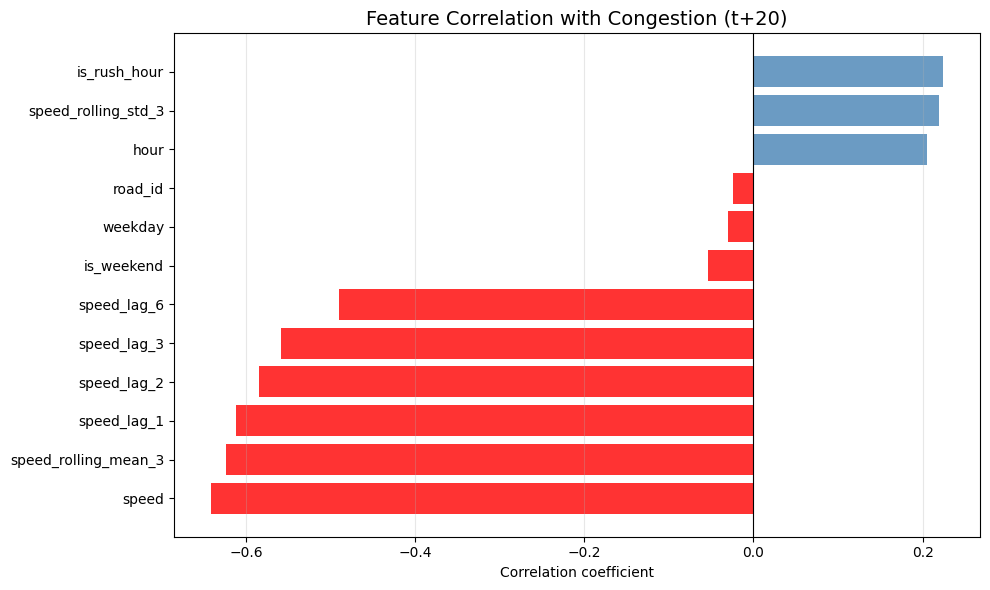

Plot saved!


In [122]:
# Correlation of features with target
correlation_df = df_merged[feature_columns + ['congestion_t20']].corr()
target_corr = correlation_df['congestion_t20'].drop(
    'congestion_t20').sort_values()

print("=== Feature Correlation with Target ===")
print(target_corr.round(3))

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['red' if x < 0 else 'steelblue' 
          for x in target_corr.values]
ax.barh(target_corr.index, target_corr.values, 
        color=colors, alpha=0.8)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Congestion (t+20)', 
             fontsize=14)
ax.set_xlabel('Correlation coefficient')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('results/figures/feature_correlation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

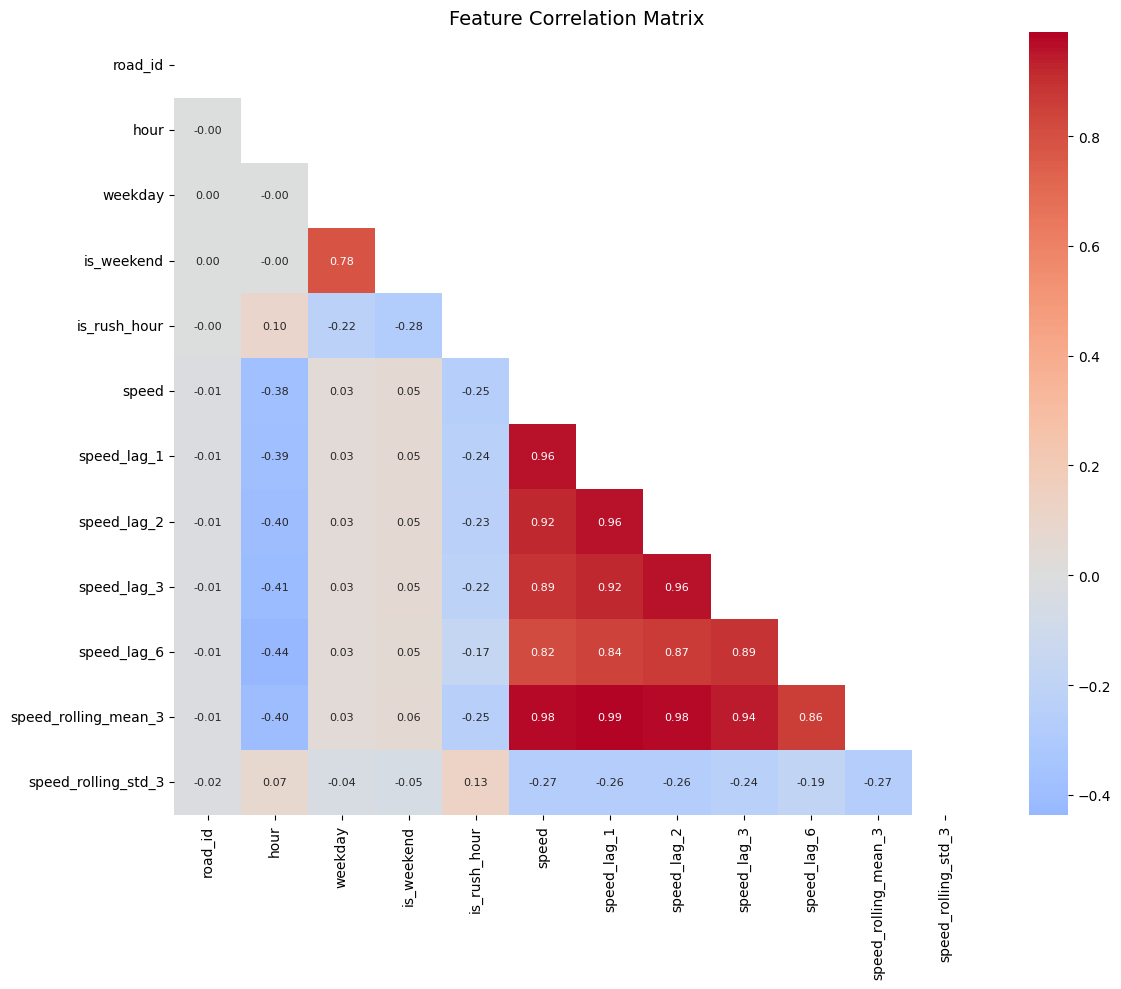

Plot saved!


In [123]:
# Correlation between features
feat_corr = X_train_scaled[feature_columns].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.zeros_like(feat_corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(feat_corr, 
            mask=mask,
            annot=True, 
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            ax=ax,
            annot_kws={'size': 8})

ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('results/figures/feature_correlation_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [124]:
total = len(X)
train_end = int(total * 0.70)
val_end = int(total * 0.85)

X_train = X.iloc[:train_end]
X_val = X.iloc[train_end:val_end]
X_test = X.iloc[val_end:]

y_train = y.iloc[:train_end]
y_val = y.iloc[train_end:val_end]
y_test = y.iloc[val_end:]

print("=== Train / Val / Test Split ===")
print(f"Train:      {len(X_train):,} rows "
      f"({len(X_train)/total*100:.1f}%)")
print(f"Validation: {len(X_val):,} rows "
      f"({len(X_val)/total*100:.1f}%)")
print(f"Test:       {len(X_test):,} rows "
      f"({len(X_test)/total*100:.1f}%)")
print(f"\nCongestion rate in each split:")
print(f"Train:      {y_train.mean()*100:.1f}%")
print(f"Validation: {y_val.mean()*100:.1f}%")
print(f"Test:       {y_test.mean()*100:.1f}%")

=== Train / Val / Test Split ===
Train:      1,297,702 rows (70.0%)
Validation: 278,079 rows (15.0%)
Test:       278,079 rows (15.0%)

Congestion rate in each split:
Train:      20.0%
Validation: 14.9%
Test:       16.3%


In [125]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert back to dataframe for readability
X_train_scaled = pd.DataFrame(
    X_train_scaled, columns=feature_columns)
X_val_scaled = pd.DataFrame(
    X_val_scaled, columns=feature_columns)
X_test_scaled = pd.DataFrame(
    X_test_scaled, columns=feature_columns)

print("Features scaled using MinMaxScaler")
print("Fitted on training data only")
print(f"\nSample of scaled training data:")
print(X_train_scaled.head(3).round(3))
print(f"\nValue ranges after scaling:")
print(X_train_scaled.describe().loc[['min','max']].round(3))

Features scaled using MinMaxScaler
Fitted on training data only

Sample of scaled training data:
   road_id   hour  weekday  is_weekend  is_rush_hour  speed  speed_lag_1  \
0      0.0  0.043      0.0         0.0           0.0  0.459        0.467   
1      0.0  0.043      0.0         0.0           0.0  0.465        0.459   
2      0.0  0.043      0.0         0.0           0.0  0.451        0.465   

   speed_lag_2  speed_lag_3  speed_lag_6  speed_rolling_mean_3  \
0        0.465        0.468        0.429                 0.554   
1        0.467        0.465        0.441                 0.554   
2        0.459        0.467        0.464                 0.547   

   speed_rolling_std_3  
0                0.014  
1                0.014  
2                0.022  

Value ranges after scaling:
     road_id  hour  weekday  is_weekend  is_rush_hour  speed  speed_lag_1  \
min      0.0   0.0      0.0         0.0           0.0    0.0          0.0   
max      1.0   1.0      1.0         1.0           

In [126]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calculate class weights from training data
classes = np.array([0, 1])
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print("=== Class Weights ===")
print(f"No congestion (0): {class_weights[0]:.4f}")
print(f"Congestion (1):    {class_weights[1]:.4f}")
print(f"\nInterpretation:")
print(f"Missing a congestion case costs "
      f"{class_weights[1]/class_weights[0]:.1f}x "
      f"more than missing a no-congestion case")

# Save for use in model notebooks
if not os.path.exists('models'):
    os.makedirs('models')
    
joblib.dump(class_weights, 'models/class_weights.pkl')
print("Class weights saved!")

=== Class Weights ===
No congestion (0): 0.6247
Congestion (1):    2.5051

Interpretation:
Missing a congestion case costs 4.0x more than missing a no-congestion case
Class weights saved!


In [127]:
# Save processed data
os.makedirs('data/processed', exist_ok=True)

# Save scaled versions
X_train_scaled.to_csv(
    'data/processed/X_train.csv', index=False)
X_val_scaled.to_csv(
    'data/processed/X_val.csv', index=False)
X_test_scaled.to_csv(
    'data/processed/X_test.csv', index=False)

# Save targets
y_train.to_csv(
    'data/processed/y_train.csv', index=False)
y_val.to_csv(
    'data/processed/y_val.csv', index=False)
y_test.to_csv(
    'data/processed/y_test.csv', index=False)

# Save scaler for later use in dashboard
import joblib
os.makedirs('models', exist_ok=True)
joblib.dump(scaler, 'models/scaler.pkl')

print("All files saved to data/processed/")
print("\nSaved files:")
for f in os.listdir('data/processed/'):
    size = os.path.getsize(f'data/processed/{f}')
    print(f"  {f}: {size/1024/1024:.1f} MB")

All files saved to data/processed/

Saved files:
  X_test.csv: 51.1 MB
  X_train.csv: 237.4 MB
  X_val.csv: 51.1 MB
  y_test.csv: 1.3 MB
  y_train.csv: 6.2 MB
  y_val.csv: 1.3 MB
